The code for 3D tomography for Aaron

In [29]:
from functools import partial
import chromatix.functional as cx
import chromatix.utils.fft as cfft
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

Creating a random 3D sample

In [5]:
def create_volume(shape):
    return np.zeros(shape)

def random_location(shape, object_shape):
    h, w, l = shape
    oh, ow, ol = object_shape
    x = np.random.randint(0, h - oh)
    y = np.random.randint(0, w - ow)
    z = np.random.randint(0, l - ol)
    return x, y, z

def add_sphere(volume, radius):
    h, w, l = volume.shape
    x0, y0, z0 = random_location(volume.shape, (radius*2, radius*2, radius*2))
    for x in range(radius*2):
        for y in range(radius*2):
            for z in range(radius*2):
                if (x-radius)**2 + (y-radius)**2 + (z-radius)**2 <= radius**2:
                    volume[x0 + x, y0 + y, z0 + z] = 1
    return volume

def add_cube(volume, side_length):
    h, w, l = volume.shape
    x0, y0, z0 = random_location(volume.shape, (side_length, side_length, side_length))
    volume[x0:x0+side_length, y0:y0+side_length, z0:z0+side_length] = 2
    return volume

def add_pyramid(volume, base_length):
    h, w, l = volume.shape
    height = base_length // 2
    x0, y0, z0 = random_location(volume.shape, (base_length, base_length, height))
    for i in range(height):
        for x in range(base_length - 2*i):
            for y in range(base_length - 2*i):
                volume[x0 + x + i, y0 + y + i, z0 + i] = 3
    return volume

def plot_volume(volume):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Get the coordinates of the voxels
    x, y, z = np.indices(volume.shape)

    # Extract the coordinates of the non-zero voxels
    x = x[volume > 0]
    y = y[volume > 0]
    z = z[volume > 0]
    values = volume[volume > 0]

    # Plot each object with different colors
    ax.scatter(x, y, z, c=values, cmap='viridis')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    plt.show()

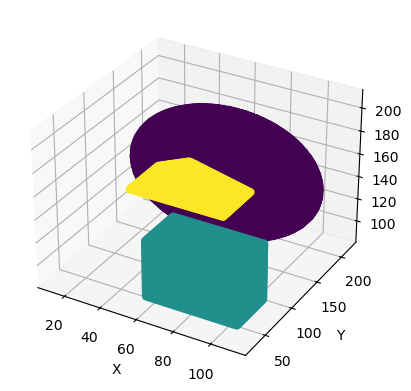

In [22]:
shape = (128, 256, 256) # depth along the axis (depth), height, width
height, width, length = shape  # Adjust the size as needed
sample_phase = create_volume(shape)
sample_phase = add_sphere(sample_phase, 50)
sample_phase = add_cube(sample_phase, 50)
sample_phase = add_pyramid(sample_phase, 50)
sample_phase /= 6
plot_volume(sample_phase)

In [62]:
#%% Global variables
key = jax.random.PRNGKey(42)
# thickness of each sample slice in microns
thickness = 1.0
# length of the field in pixels
size = shape[1:]
# pixel spacing
dx = 0.1154
# wavelength in microns
wavelength = 0.523
# power is 1 per pixel
power = np.prod(size) * dx * dx

def generate_hologram(sample_delay, sample_absorption):
    ref_field = cx.plane_wave(
        shape=size,
        dx=dx,
        spectrum=wavelength,
        spectral_density=1.0,
        power=power,
        kykx = (18/np.sqrt(2), 18/np.sqrt(2))
    )
    sample_field = cx.plane_wave(
        shape=size,
        dx=dx,
        spectrum=wavelength,
        spectral_density=1.0,
        power=power
    )
    sample_field = cx.multislice_thick_sample(
        sample_field,
        sample_absorption,
        sample_delay,
        1.33,
        thickness,
        N_pad=0,
    )
    return ref_field + sample_field

background_hologram = generate_hologram(sample_delay=np.zeros_like(sample_phase),
                            sample_absorption=np.zeros_like(sample_phase))
sample_hologram = generate_hologram(sample_delay=sample_phase,
                            sample_absorption=np.zeros_like(sample_phase))


fft_background = cfft.fft(background_hologram.intensity,
                        shift=True).squeeze()

fft_sample = cfft.fft(sample_hologram.intensity,
                        shift=True).squeeze()



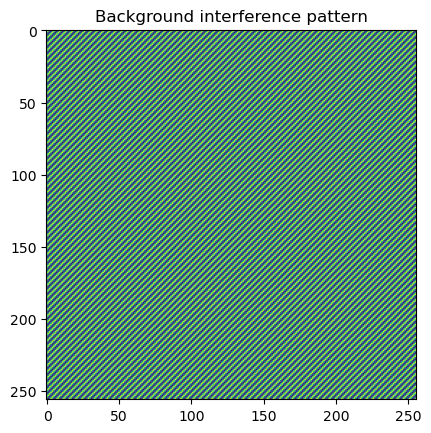

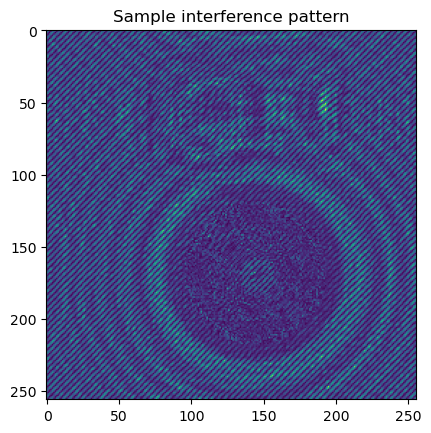

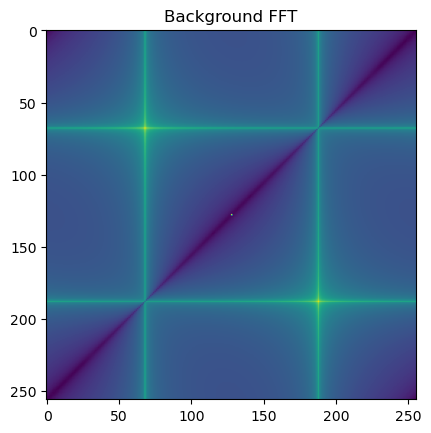

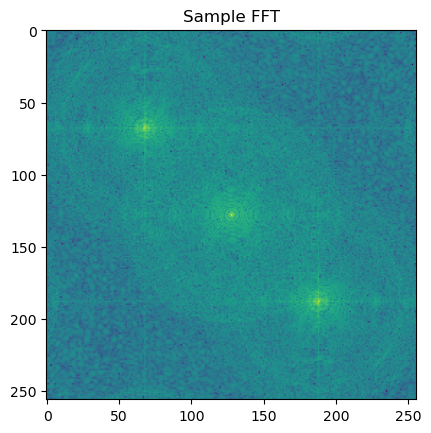

In [64]:
plt.imshow(background_hologram.intensity.squeeze())
plt.title('Background interference pattern')
plt.show()
plt.imshow(sample_hologram.intensity.squeeze())
plt.title('Sample interference pattern')
plt.show()
plt.imshow(np.log(np.abs(np.array(fft_background)))+1.0)
plt.title('Background FFT')
plt.show()
plt.imshow(np.log(np.abs(np.array(fft_sample)))+1.0)
plt.title('Sample FFT')
plt.show()
